In [88]:
from utils import *
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'

# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


# Part 1 plot coherence state

In [5]:
import pickle
with open('mcsolve_detection_results_kappa1e-3.pkl', 'rb') as file:
    detection_results_1em3 = pickle.load(file)
with open('mcsolve_detection_results_kappa2e-3.pkl', 'rb') as file:
    detection_results_2em3 = pickle.load(file)
with open('mcsolve_detection_results_kappa5e-3.pkl', 'rb') as file:
    detection_results_5em3 = pickle.load(file)

-0.279748253707043


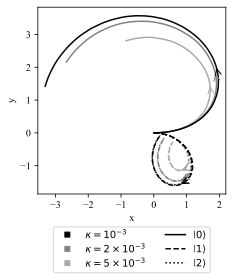

In [160]:
tot_time =478
tlist = np.linspace(0, tot_time, tot_time)
first_dominant_freq =find_dominant_frequency(detection_results_1em3[1].expect[0],tlist)
print(first_dominant_freq)

nlevels = 3

plt.figure(figsize=(3+3/8,3+3/8))

black_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='black', linestyle='-')
gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='gray', linestyle='-')
dark_gray_line, = plt.plot([], [], marker="s", markersize=5, linewidth=0, color='darkgray', linestyle='-')

solid_line, = plt.plot([], [], color='black', linestyle='-')
dashed_line, = plt.plot([], [], color='black', linestyle='--')
dot_line, = plt.plot([], [], color='black', linestyle=':')

legend_lines = (black_line, gray_line, dark_gray_line,
                solid_line,dashed_line,dot_line)
legend_labels = (r'$\kappa=10^{-3}$',r'$\kappa=2\times10^{-3}$',r'$\kappa=5\times10^{-3}$', 
                 rf'$\left|{0}\right>$',rf'$\left|{1}\right>$',rf'$\left|{2}\right>$')

def add_arrow(line, position=None, direction='right', size=15, color=None):
    """
    add an arrow to a line.

    line:       Line2D object
    position:   x-position of the arrow. If None, mean of xdata is taken
    direction:  'left' or 'right'
    size:       size of the arrow in fontsize points
    color:      if None, line color is taken.

    based on: https://stackoverflow.com/questions/34017866/arrow-on-a-line-plot
    """
    if color is None:
        color = line.get_color()

    xdata = line.get_xdata()
    ydata = line.get_ydata()


    start_ind = int(len(xdata)/2)
    if direction == 'right':
        end_ind = start_ind + 1
    else:
        end_ind = start_ind - 1

    line.axes.annotate('',
        xytext=(xdata[start_ind], ydata[start_ind]),
        xy=(xdata[end_ind], ydata[end_ind]),
        arrowprops=dict(arrowstyle="->", color=color),
        size=size
    )

# different settings have different color
for results,kappa,color in reversed(list(zip([detection_results_1em3,detection_results_2em3,detection_results_5em3],["10^{-3}",r"2\times10^{-3}",r"5\times10^{-3}"],['black','gray','darkgray']))):
    # different initial states has different line shape

    for i, linestype in zip([0,1,2],['-',':','--']):
        alpha = results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        line, = plt.plot(-alpha.imag,alpha.real,label=rf'$\left|{i}\right>,\kappa={kappa}$',color=color,linestyle=linestype)
        add_arrow(line)

plt.xlim(-4,4)
plt.ylim(-4,4)

plt.legend(legend_lines, legend_labels,
            loc='upper center', 
            bbox_to_anchor=(0.5, -0.15), 
            ncol=2)
plt.axis('equal')
plt.savefig("fig05_alpha.pdf", format='pdf', bbox_inches='tight')

plt.xlabel('x')
plt.ylabel('y')
plt.show()



# Plot integrated contrast

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_33887/2523422885.py: 20

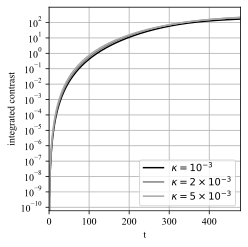

In [156]:
plt.figure(figsize=(3+3/8,3+3/8))

for results,kappa,kappa_val,color in zip([detection_results_1em3,detection_results_2em3,detection_results_5em3],
                                         ["10^{-3}",r"2\times10^{-3}",r"5\times10^{-3}"],
                                         [1e-3,2e-3,5e-3],
                                         ['black','gray','darkgray']):
    alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alpha1 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    squared_diff = np.square(abs(alpha0-alpha1))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                         )
        
    plt.plot(tlist,integrals,label=rf'$\kappa={kappa}$',color=color)

plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()



# Plot infidelity

In [122]:
with open('mcsolve_infidelity_kappa1e-3.pkl', 'rb') as file:
    infidelity_1em3 = pickle.load(file)
with open('mcsolve_infidelity_kappa2e-3.pkl', 'rb') as file:
    infidelity_2em3 = pickle.load(file)
with open('mcsolve_infidelity_kappa5e-3.pkl', 'rb') as file:
    infidelity_5em3 = pickle.load(file)


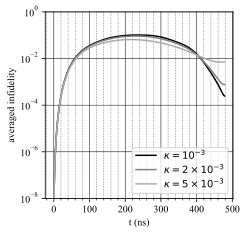

In [130]:
plt.figure(figsize=(3+3/8,3+3/8))

for infidelities,kappa,color in zip([infidelity_1em3,infidelity_2em3,infidelity_5em3],
                                         ["10^{-3}",r"2\times10^{-3}",r"5\times10^{-3}"],
                                         ['black','gray','darkgray']):
    plt.plot(tlist,infidelities,label=rf'$\kappa={kappa}$',color=color)

plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(1e-8,1)
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.xlabel("t (ns)")
plt.ylabel('averaged infidelity')
plt.savefig("fig07_infidelities.pdf", format='pdf', bbox_inches='tight')
plt.show()

